In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [2]:
import os
os.listdir('/kaggle/input')

['competitions']

In [3]:
os.listdir('/kaggle/input/competitions/playground-series-s6e3')

['sample_submission.csv', 'train.csv', 'test.csv']

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (594194, 21)
Test shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [5]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [6]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [7]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


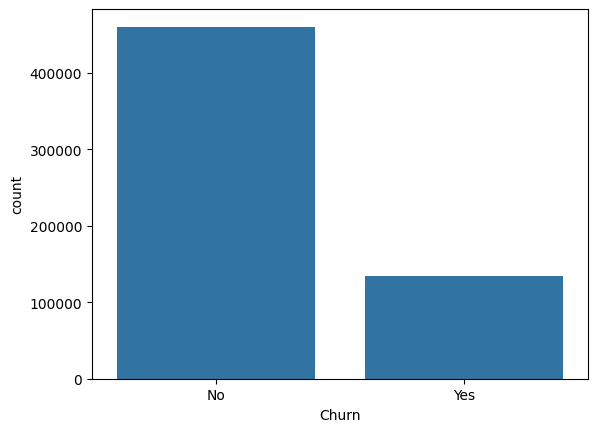

Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

In [8]:
sns.countplot(x="Churn", data=train)
plt.show()

train["Churn"].value_counts(normalize=True)

In [9]:
cat_cols = train.select_dtypes(include=['object']).columns
num_cols = train.select_dtypes(exclude=['object']).columns

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')
Numerical: Index(['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [10]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    if col != "Churn":
        le = LabelEncoder()
        combined = list(train[col]) + list(test[col])
        le.fit(combined)
        train[col] = le.transform(train[col])
        test[col] = le.transform(test[col])

In [11]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,1,29,1,0,0,2,...,2,2,0,0,1,1,3,60.10,1653.85,No
1,1,1,0,1,1,58,1,0,0,2,...,0,2,2,0,2,0,1,69.50,3778.20,No
2,2,1,0,1,0,58,1,2,1,0,...,0,0,2,2,0,1,2,100.40,5841.35,No
3,3,0,0,0,0,1,1,0,1,0,...,0,0,0,0,0,1,2,69.70,70.70,Yes
4,4,0,0,0,0,1,1,0,1,0,...,0,0,0,0,0,1,2,70.45,70.45,Yes


In [12]:
train.columns
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  int64  
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  int64  
 4   Dependents        594194 non-null  int64  
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  int64  
 7   MultipleLines     594194 non-null  int64  
 8   InternetService   594194 non-null  int64  
 9   OnlineSecurity    594194 non-null  int64  
 10  OnlineBackup      594194 non-null  int64  
 11  DeviceProtection  594194 non-null  int64  
 12  TechSupport       594194 non-null  int64  
 13  StreamingTV       594194 non-null  int64  
 14  StreamingMovies   594194 non-null  int64  
 15  Contract          594194 non-null  int64  
 16  PaperlessBilling  59

In [13]:
print(train.columns)

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [14]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,1,29,1,0,0,2,...,2,2,0,0,1,1,3,60.10,1653.85,No
1,1,1,0,1,1,58,1,0,0,2,...,0,2,2,0,2,0,1,69.50,3778.20,No
2,2,1,0,1,0,58,1,2,1,0,...,0,0,2,2,0,1,2,100.40,5841.35,No
3,3,0,0,0,0,1,1,0,1,0,...,0,0,0,0,0,1,2,69.70,70.70,Yes
4,4,0,0,0,0,1,1,0,1,0,...,0,0,0,0,0,1,2,70.45,70.45,Yes


In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  int64  
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  int64  
 4   Dependents        594194 non-null  int64  
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  int64  
 7   MultipleLines     594194 non-null  int64  
 8   InternetService   594194 non-null  int64  
 9   OnlineSecurity    594194 non-null  int64  
 10  OnlineBackup      594194 non-null  int64  
 11  DeviceProtection  594194 non-null  int64  
 12  TechSupport       594194 non-null  int64  
 13  StreamingTV       594194 non-null  int64  
 14  StreamingMovies   594194 non-null  int64  
 15  Contract          594194 non-null  int64  
 16  PaperlessBilling  59

In [16]:
train.describe()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.497238,0.114102,0.520965,0.302649,36.577258,0.938907,0.985064,0.932086,0.788821,0.921408,0.930516,0.791861,1.045667,1.049484,0.811551,0.615252,1.574772,65.866223,2494.377057
std,171529.177262,0.499993,0.317936,0.499561,0.459405,25.061922,0.239501,0.968858,0.732786,0.847684,0.870050,0.870825,0.848435,0.872398,0.872190,0.884403,0.486536,1.034143,31.067444,2353.916710
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000
25%,148548.250000,0.000000,0.000000,0.000000,0.000000,12.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,29.900000,639.650000
50%,297096.500000,0.000000,0.000000,1.000000,0.000000,35.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,74.100000,1433.650000
75%,445644.750000,1.000000,0.000000,1.000000,1.000000,62.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,90.800000,4263.800000
max,594193.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000


In [17]:
train['Churn'].value_counts()
train['Churn'].value_counts(normalize=True)

Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

In [18]:
if 'id' in train.columns:
    train = train.drop(columns=['id'])

In [19]:
# 1. Save the IDs for later (only if they exist in the dataframe)
if 'id' in test.columns:
    test_ids = test['id']
    # 2. Drop 'id' from test so it matches training features
    test = test.drop(columns=['id'])
    print("Successfully extracted IDs and dropped column.")
else:
    print("Column 'id' was already removed or doesn't exist.")

# Display the first few rows to confirm it looks right
test.head()

    

Successfully extracted IDs and dropped column.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,72,1,2,1,2,2,2,2,2,2,2,1,2,115.55,8061.50
1,0,0,1,0,71,1,0,2,1,1,1,1,1,1,2,0,0,19.80,1336.50
2,1,0,0,0,12,1,0,0,2,2,0,0,0,0,0,1,0,55.55,633.55
3,1,0,1,1,71,1,2,0,2,0,2,2,2,2,2,0,1,84.10,6457.15
4,0,0,0,0,15,1,0,1,2,0,0,0,2,2,0,0,2,90.35,1233.65


In [20]:
# Separate the target first so it doesn't get encoded
y = train['Churn'].map({'Yes': 1, 'No': 0})
X = train.drop(columns=['Churn'])

# Convert text columns into numbers (One-Hot Encoding)
X = pd.get_dummies(X)
test_final = pd.get_dummies(test)


X, test_final = X.align(test_final, join='left', axis=1, fill_value=0)


In [21]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Train the model
model.fit(X, y)
print("Model training complete!")


Model training complete!


In [22]:
# Predict probabilities (usually better for Kaggle scores than hard 0/1)
predictions = model.predict_proba(test_final)[:, 1]

# Create the final dataframe
submission = pd.DataFrame({
    "id": test_ids,
    "Churn": predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("Submission file saved as submission.csv!")


Submission file saved as submission.csv!
